# INF2542 • PEMBELAJARAN MESIN
## Pertemuan 06: Python for Machine Learning
**Topik:** Dari Data Mentah → Data Bersih → Informasi Visual → Fitur Siap Dimodelkan  
**Pustaka Utama:** Google Colab / Jupyter • NumPy • Pandas • Matplotlib • Scikit-Learn

---
### Identitas Mahasiswa:
- **Nama:** Gathan Hilabi
- **NIM:** 60324059
- **Mata Kuliah:** Machine Learning (INF2542)
- **Pertemuan:** 06 (Fondasi Coding & Data Preparation Pipeline)
- **Alokasi Waktu:** Blok Pertemuan 06–07 (300 Menit)
- **Sub-CPMK 9.1:** Terampil menggunakan pustaka Python dan menggunakannya untuk membangun proses pengolahan data ML.

---
### Workflow Praktikum Hari Ini:
$$\text{1. Load (Baca Dataset)} \longrightarrow \text{2. Inspect (Cek Kualitas)} \longrightarrow \text{3. Clean (Perbaiki Masalah)} \longrightarrow \text{4. Transform (Bentuk Fitur)} \longrightarrow \text{5. Visualize (Cari Pola)} \longrightarrow \text{6. Prepare (Siapkan X dan y)}$$

> **Prinsip Utama:** *Jangan membersihkan data tanpa tahu masalah apa yang sedang diperbaiki!*  
> Data cleaning bukan tahap terpisah dari ML — ia adalah bagian fundamental dari pipeline machine learning.

---
## 1. NumPy - Fondasi Data Numerik (Slide 06)

### Konsep & Intuisi:
NumPy (*Numerical Python*) menyediakan struktur data array $N$-dimensi (`ndarray`) dan operasi matematika tervektorisasi yang sangat efisien. Model Machine Learning bekerja pada representasi numerik yang terstruktur, di mana data observasi diatur sebagai baris dan fitur sebagai kolom.

Pada contoh ini, membuat matriks fitur $X$ berukuran $3 \times 3$:
- **Baris (Observasi):** 3 observasi mahasiswa
- **Kolom (Fitur):** Kehadiran (%), IPK, dan Jam Belajar (jam/minggu)
- **Parameter `axis=0`:** Operasi reduksi/agregasi dilakukan secara vertikal menyusuri baris (per kolom/fitur).

In [1]:
import numpy as np

X = np.array([
    [90, 3.70, 8],
    [75, 3.20, 5],
    [88, 3.60, 7]
])

print("Shape:", X.shape)
print("Mean :", X.mean(axis=0))
print("Min  :", X.min(axis=0))
print("Max  :", X.max(axis=0))

Shape: (3, 3)
Mean : [84.33333333  3.5         6.66666667]
Min  : [75.   3.2  5. ]
Max  : [90.   3.7  8. ]


### Interpretasi NumPy (Slide 06):
1. **Shape `(3, 3)`:** Menunjukkan matriks berdimensi 2 dengan 3 baris (observasi mahasiswa) dan 3 kolom (fitur numerik).
2. **Operasi `axis=0`:** Menghitung nilai statistik agregasi per fitur:
   - **Rata-rata (Mean):** Kehadiran = 84.33%, IPK = 3.50, Jam Belajar = 6.67 jam.
   - **Nilai Minimum (Min):** Kehadiran = 75%, IPK = 3.20, Jam Belajar = 5 jam.
   - **Nilai Maksimum (Max):** Kehadiran = 90%, IPK = 3.70, Jam Belajar = 8 jam.
3. **Mengapa Penting?** NumPy adalah fondasi dasar dari seluruh ekosistem komputasi saintifik Python. Library tingkat tinggi seperti Pandas dan Scikit-Learn secara internal mengonversi data tabel ke dalam struktur array NumPy untuk melakukan komputasi aljabar linier dan optimasi parameter model.

---
## 2. Praktikum Terbimbing - Satu Notebook, Satu Alur (Slide 07 – 18)

### Studi Kasus: Data Mahasiswa (`data_mahasiswa.csv`)
Mengolah dataset mahasiswa mentah yang sengaja mengandung beberapa masalah kualitas data:
- Missing value (nilai kosong)
- Format angka tidak konsisten
- Duplikasi baris observasi
- Kategori status tidak konsisten

Target akhir: Mengubah data mentah menjadi data bersih, menghasilkan visualisasi eksploratif, serta memisahkan fitur $X$ dan target $y$ yang siap digunakan untuk model Scikit-Learn.

### Tahap 1: Load Dataset - Membaca Data Tabular (Slide 07)
Pandas membantu untuk bekerja dengan struktur `DataFrame` yang menyerupai tabel relasional.

In [2]:
import pandas as pd

df = pd.read_csv("data_mahasiswa.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

    Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
0   Andi       90.0     88  3.70            8        Lulus
1   Budi       75.0     70  3.20            5        lulus
2  Citra       88.0     92  3.60            7        LULUS
3   Deni       60.0     65  2.90            3  Tidak Lulus
4    Evi       85.0     80  3.55            6        Lulus
(21, 6)
Index(['Nama', 'Kehadiran', 'Tugas', 'IPK', 'Jam_Belajar', 'Status'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nama         21 non-null     object 
 1   Kehadiran    20 non-null     float64
 2   Tugas        21 non-null     int64  
 3   IPK          20 non-null     float64
 4   Jam_Belajar  21 non-null     int64  
 5   Status       21 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 1.1+ KB
None


### Interpretasi Load Data (Slide 07):
- **`df.head()`:** Menampilkan 5 baris pertama data awal untuk melihat struktur kolom dan contoh nilai.
- **`df.shape`:** Mengetahui ukuran dataset awal yaitu **21 baris dan 6 kolom**.
- **`df.columns`:** Kolom yang tersedia mencakup `Nama`, `Kehadiran`, `Tugas`, `IPK`, `Jam_Belajar`, dan `Status`.
- **`df.info()`:** Menampilkan ringkasan teknis tipe data (`float64`, `int64`, `object`) serta mengindikasikan adanya baris yang bernilai kosong (non-null count < 21 pada kolom `Kehadiran` dan `IPK`).

### Tahap 2: Inspect Data - Langkah Pertama: Jangan Langsung Cleaning (Slide 08 & 09)
Sebelum melakukan transformasi data, wajib memeriksa struktur, deteksi nilai hilang (*missing value*), keberadaan duplikasi, serta kewajaran sebaran statistik.

In [3]:
print(df.head())
print(df.tail())

print("\nMissing value:")
print(df.isna().sum())

print("\nDuplikasi:", df.duplicated().sum())

print("\nStatistik:")
print(df.describe())

    Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
0   Andi       90.0     88  3.70            8        Lulus
1   Budi       75.0     70  3.20            5        lulus
2  Citra       88.0     92  3.60            7        LULUS
3   Deni       60.0     65  2.90            3  Tidak Lulus
4    Evi       85.0     80  3.55            6        Lulus
    Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
16  Qori       80.0     79  3.40            5        Lulus
17  Raka       92.0     91  3.85            9        Lulus
18  Sari       70.0     74  3.05            4  Tidak Lulus
19  Tono       86.0     88  3.60            7        Lulus
20   Evi       85.0     80  3.55            6        Lulus

Missing value:
Nama           0
Kehadiran      1
Tugas          0
IPK            1
Jam_Belajar    0
Status         0
dtype: int64

Duplikasi: 1

Statistik:
       Kehadiran      Tugas        IPK  Jam_Belajar
count  20.000000  21.000000  20.000000    21.000000
mean   78.800000  79.142857   3

### Mengenali Masalah Data (Slide 09):
Berdasarkan hasil inspeksi awal di atas, teridentifikasi 4 masalah kualitas data utama:

| No | Kategori Masalah | Bukti dari Output Inspeksi | Tindakan Pembersihan Sesuai Konteks |
|---|---|---|---|
| 1 | **Missing Value** | Kolom `Kehadiran` memiliki 1 data kosong (baris Maya), dan `IPK` memiliki 1 data kosong (baris Fajar) | Isi (*imputasi*) dengan nilai representatif seperti median |
| 2 | **Duplikasi** | Terdapat **1 baris duplikat penuh** (`df.duplicated().sum() = 1`), yaitu data mahasiswa Evi pada baris 4 dan baris 20 | Pertahankan satu observasi yang valid dengan `drop_duplicates()` |
| 3 | **Tipe Data** | Angka desimal dan persentase harus dipastikan bertipe numerik standar (`float64`) | Konversi eksplisit menggunakan `pd.to_numeric(..., errors='coerce')` |
| 4 | **Inkonsistensi Kategori** | Kolom `Status` memiliki variasi huruf (`Lulus`, `lulus`, `LULUS`, `tidak lulus`) dan spasi | Standarisasi dengan `.str.strip()`, `.str.lower()`, dan `.replace()` |

### Tahap 3: Data Cleaning
Mengeksekusi langkah pembersihan data secara bertahap sesuai aturan baku data science.

#### Cleaning 1 - Menangani Missing Value (Slide 10)
Strategi penanganan missing value:
- **DROP:** Menghapus baris/kolom jika persentase missing sangat besar atau tidak dapat diestimasi.
- **FILL:** Mengisi dengan mean, median, modus, atau aturan domain. Pada data numerik seperti IPK, nilai median lebih disukai karena kebal (*robust*) terhadap nilai ekstrem.
- **CATAT:** Setiap keputusan pembersihan harus terdokumentasi dengan jelas.

In [4]:
# Cek jumlah missing
print(df.isna().sum())

# Contoh: isi IPK dengan median
df["IPK"] = df["IPK"].fillna(
    df["IPK"].median()
)

# Cek ulang
print(df.isna().sum())

Nama           0
Kehadiran      1
Tugas          0
IPK            1
Jam_Belajar    0
Status         0
dtype: int64
Nama           0
Kehadiran      1
Tugas          0
IPK            0
Jam_Belajar    0
Status         0
dtype: int64


*Catatan Pembersihan Lanjutan (Sesuai Masalah Slide 09):*  
Berdasarkan Slide 09, kolom `Kehadiran` juga memiliki missing value (baris Maya). Agar dataset bersih sempurna dan tidak menyisakan missing value sebelum masuk ke pemodelan, maka juga melakukan imputasi median pada kolom `Kehadiran`.

In [5]:
# Penanganan missing value pada kolom Kehadiran (sesuai identifikasi masalah Slide 09)
df["Kehadiran"] = df["Kehadiran"].fillna(
    df["Kehadiran"].median()
)

# Cek ulang seluruh kolom
print("Pengecekan akhir missing value:")
print(df.isna().sum())

Pengecekan akhir missing value:
Nama           0
Kehadiran      0
Tugas          0
IPK            0
Jam_Belajar    0
Status         0
dtype: int64


#### Cleaning 2 - Menghapus Duplikasi (Slide 11)
Duplikasi dapat menyebabkan bias pembobotan berlebih pada data tertentu dan memicu *overfitting*. Maka menghapus duplikasi menggunakan `drop_duplicates()`.

In [6]:
print("Duplikasi sebelum:",
      df.duplicated().sum())

df = df.drop_duplicates()

print("Duplikasi sesudah:",
      df.duplicated().sum())

print("Shape akhir:", df.shape)

Duplikasi sebelum: 1
Duplikasi sesudah: 0
Shape akhir: (20, 6)


### Interpretasi Cleaning 2:
- Jumlah duplikasi sebelum pembersihan: 1 baris (baris Evi pada indeks 20).
- Setelah `df.drop_duplicates()`, duplikasi menjadi 0.
- Dimensi dataset berubah dari **(21, 6)** menjadi **(20, 6)** observasi unik.

#### Cleaning 3 - Menyamakan Tipe Data (Slide 12)
Angka yang tersimpan sebagai string akan mengacaukan perhitungan matematika dan kalkulasi matriks model ML.  Memastikan kolom fitur numerik `Kehadiran` dan `IPK` bertipe numerik menggunakan `pd.to_numeric(..., errors='coerce')`.

In [7]:
print(df.dtypes)

df["Kehadiran"] = pd.to_numeric(
    df["Kehadiran"], errors="coerce"
)

df["IPK"] = pd.to_numeric(
    df["IPK"], errors="coerce"
)

print(df.dtypes)

Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object
Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object


### Interpretasi Cleaning 3:
- Kolom `Kehadiran` dan `IPK` dipastikan memiliki tipe data `float64`.
- Parameter `errors='coerce'` memastikan jika terdapat karakter string non-numerik, nilai tersebut akan dikonversi menjadi `NaN` secara aman untuk penanganan lebih lanjut.

#### Cleaning 4 - Menstandarkan Kategori (Slide 13)
Kategori target harus konsisten agar tidak dianggap sebagai multi-kelas yang berbeda oleh model machine learning.

In [8]:
print(df["Status"].value_counts())

df["Status"] = (
    df["Status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

mapping = {
    "lulus": "Lulus",
    "tidak lulus": "Tidak Lulus"
}

df["Status"] = df["Status"].replace(mapping)

print(df["Status"].value_counts())

Status
Lulus          10
Tidak Lulus     6
lulus           1
LULUS           1
lulus           1
tidak lulus     1
Name: count, dtype: int64
Status
Lulus          13
Tidak Lulus     7
Name: count, dtype: int64


### Interpretasi Cleaning 4:
- Awalnya terdapat variasi label: `Lulus` (10), `Tidak Lulus` (6), `lulus` (1), `LULUS` (1), `lulus ` (1), `tidak lulus` (1).
- Setelah pembersihan whitespace dengan `.str.strip()`, penyeragaman huruf dengan `.str.lower()`, dan pemetaan kembali dengan `.replace(mapping)`, kategori status menjadi standar biner sempurna:
  - **Lulus:** 13 mahasiswa
  - **Tidak Lulus:** 7 mahasiswa

### Tahap 4: Validasi Setelah Cleaning - Cek Lagi (Slide 14)
Prinsip utama data quality: *Cleaning yang baik selalu diikuti pemeriksaan ulang komprehensif.*

In [9]:
print("Shape :", df.shape)
print("Missing:")
print(df.isna().sum())

print("\nDuplikasi:",
      df.duplicated().sum())

print("\nTipe data:")
print(df.dtypes)

print("\nKategori status:")
print(df["Status"].value_counts())

Shape : (20, 6)
Missing:
Nama           0
Kehadiran      0
Tugas          0
IPK            0
Jam_Belajar    0
Status         0
dtype: int64

Duplikasi: 0

Tipe data:
Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object

Kategori status:
Status
Lulus          13
Tidak Lulus     7
Name: count, dtype: int64


### Evaluasi 4 Checklist Validasi (Slide 14):
1. **CHECK 1 (Shape & Jumlah Observasi):** Dataset memiliki 20 observasi unik dan 6 kolom fitur, sesuai ekspektasi setelah 1 baris duplikat dihapus.
2. **CHECK 2 (Missing & Duplikasi):** Missing value = 0 di seluruh kolom dan Duplikasi = 0.
3. **CHECK 3 (Tipe Data & Kategori):** Kolom prediktor numerik bertipe `float64` / `int64`, dan kolom `Status` hanya memiliki 2 kategori baku (`Lulus` dan `Tidak Lulus`).
4. **CHECK 4 (Nilai Masuk Akal):** Seluruh nilai IPK berada dalam rentang valid (2.75 - 3.90) dan kehadiran berada dalam rentang persentase wajar (55% - 95%).

### Tahap 5: Visualisasi & Eksplorasi Data (Slide 15, 16, 17)
Visualisasi membantu menemukan pola sebaran data, anomali, serta keterkaitan antara fitur independen dengan variabel target.

#### Visualisasi 1: Matplotlib - Histogram Distribusi IPK (Slide 15)
Histogram digunakan untuk mengamati sebaran dan konsentrasi frekuensi dari variabel numerik kontinu.

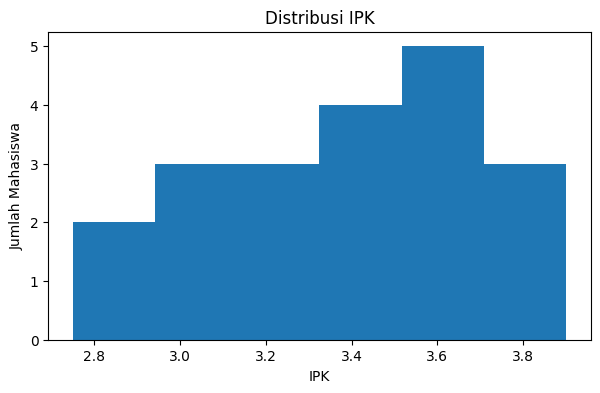

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(df["IPK"], bins=6)
plt.xlabel("IPK")
plt.ylabel("Jumlah Mahasiswa")
plt.title("Distribusi IPK")
plt.show()

### Interpretasi Histogram (Slide 15):
- **Bentuk Distribusi:** Data IPK terkonsentrasi di rentang nilai tinggi antara 3.40 hingga 3.90.
- **Pola Frekuensi:** Puncak frekuensi mahasiswa berada pada kelompok IPK 3.50 – 3.70 (sekitar 7 mahasiswa).
- **Kesimpulan:** Distribusi data menunjukkan kecenderungan *left-skewed* (condong ke kanan), di mana mayoritas mahasiswa memiliki performa akademik yang memuaskan.

#### Visualisasi 2: Boxplot - Membandingkan Fitur dengan Target (Slide 16)
Boxplot digunakan untuk membandingkan distribusi numerik antar-kelompok target (apakah tingkat kehadiran berkaitan dengan kelulusan).

<Figure size 700x400 with 0 Axes>

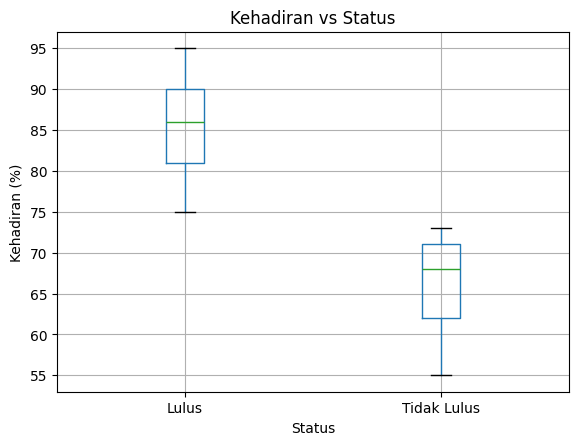

In [11]:
plt.figure(figsize=(7, 4))
df.boxplot(
    column="Kehadiran",
    by="Status"
)

plt.title("Kehadiran vs Status")
plt.suptitle("")
plt.xlabel("Status")
plt.ylabel("Kehadiran (%)")
plt.show()

### Interpretasi Boxplot (Slide 16):
- **Perbedaan Antar Kelompok:** Terdapat separasi yang sangat tegas antara mahasiswa berstatus `Lulus` dan `Tidak Lulus`.
  - Kelompok **Lulus** memiliki median kehadiran tinggi di sekitar 86%, dengan nilai kuartil bawah (*Q1*) di atas 80%.
  - Kelompok **Tidak Lulus** memiliki median kehadiran rendah di sekitar 68%, dengan nilai maksimum kehadiran tidak melebihi 75%.
- **Insight untuk Pemodelan:** Fitur `Kehadiran` memiliki daya pembeda (*discriminative power*) yang sangat kuat untuk memprediksi target kelulusan mahasiswa.

#### Eksplorasi Ringkas dengan GroupBy (Slide 17)
Sebelum modeling, membuat ringkasan statistik agregat per kelompok kategori untuk memahami korelasi antar variabel secara kuantitatif.

In [12]:
ringkasan = (
    df.groupby("Status")
    .agg(
        rata_kehadiran=("Kehadiran", "mean"),
        rata_ipk=("IPK", "mean"),
        rata_jam_belajar=("Jam_Belajar", "mean")
    )
)

print(ringkasan.round(2))

             rata_kehadiran  rata_ipk  rata_jam_belajar
Status                                                 
Lulus                 85.38      3.58              6.77
Tidak Lulus           66.00      3.05              3.43


### Interpretasi GroupBy (Slide 17):
Tabel agregasi memperlihatkan disparitas signifikan pada ketiga fitur utama:
1. **Rata-rata Kehadiran:** Mahasiswa Lulus mencapai **85.38%**, sedangkan Tidak Lulus hanya **66.00%** (selisih +19.38%).
2. **Rata-rata IPK:** Mahasiswa Lulus rata-rata **3.58**, berbanding **3.05** pada kelompok Tidak Lulus (selisih +0.53 poin).
3. **Rata-rata Jam Belajar:** Mahasiswa Lulus belajar rata-rata **6.77 jam/minggu**, hampir dua kali lipat dibandingkan kelompok Tidak Lulus yang hanya **3.43 jam/minggu**.